# Part 1.3 – Machine Learning Analysis

This notebook analyses two retail datasets using two regression algorithms:

- Random Forest Regressor
- Gradient Boosting Regressor

The Superstore dataset is used to predict **Profit**, while the Retail Store Inventory dataset is used to predict **Units Sold**.

Evaluation metrics used:
- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- R² score

> Place `sample_-_superstore.csv` and `retail_store_inventory.csv` in the same folder as this notebook before running it.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
print("Libraries imported successfully.")

Libraries imported successfully.


## Dataset 1 – Superstore

In [2]:
superstore = pd.read_csv("sample_-_superstore.csv")

print("Superstore dataset shape:", superstore.shape)
print("\nColumns:")
print(superstore.columns.tolist())

print("\nFirst five rows:")
display(superstore.head())

Superstore dataset shape: (10194, 21)

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

First five rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,State/Province,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,01/03/2023,01/07/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,Texas,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,01/04/2023,01/08/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,Illinois,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,01/05/2023,01/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,Pennsylvania,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [3]:
print("Missing values:")
print(superstore.isnull().sum())

print("\nSummary statistics:")
display(superstore[["Sales", "Quantity", "Discount", "Profit"]].describe())

Missing values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

Summary statistics:


,Sales,Quantity,Discount,Profit
count,10194.000000,10194.000000,10194.000000,10194.000000
mean,228.225854,3.791838,0.155385,28.673417
std,619.906839,2.228317,0.206249,232.465115
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.220000,2.000000,0.000000,1.760800
50%,53.910000,3.000000,0.200000,8.690000
75%,209.500000,5.000000,0.200000,29.297925
max,22638.480000,14.000000,0.800000,8399.976000


### Superstore modelling setup

The target variable is **Profit**. Sales, quantity, discount and selected categorical business attributes are used as predictors.

In [4]:
superstore_features = [
    "Sales",
    "Quantity",
    "Discount",
    "Category",
    "Sub-Category",
    "Region",
    "Segment",
    "Ship Mode"
]

X_superstore = superstore[superstore_features]
y_superstore = superstore["Profit"]

numeric_superstore = ["Sales", "Quantity", "Discount"]

categorical_superstore = [
    "Category",
    "Sub-Category",
    "Region",
    "Segment",
    "Ship Mode"
]

superstore_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", "passthrough", numeric_superstore),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_superstore)
    ]
)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_superstore,
    y_superstore,
    test_size=0.20,
    random_state=42
)

print("Features used:", superstore_features)
print("Target variable: Profit")
print("Training records:", X_train_s.shape[0])
print("Testing records:", X_test_s.shape[0])

Features used: ['Sales', 'Quantity', 'Discount', 'Category', 'Sub-Category', 'Region', 'Segment', 'Ship Mode']
Target variable: Profit
Training records: 8155
Testing records: 2039


### Random Forest – Superstore

In [5]:
rf_superstore = Pipeline(
    steps=[
        ("preprocessor", superstore_preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_superstore.fit(X_train_s, y_train_s)
rf_predictions_s = rf_superstore.predict(X_test_s)

rf_mae_s = mean_absolute_error(y_test_s, rf_predictions_s)
rf_rmse_s = np.sqrt(mean_squared_error(y_test_s, rf_predictions_s))
rf_r2_s = r2_score(y_test_s, rf_predictions_s)

print("SUPERSTORE - RANDOM FOREST")
print("MAE :", round(rf_mae_s, 2))
print("RMSE:", round(rf_rmse_s, 2))
print("R²  :", round(rf_r2_s, 3))

SUPERSTORE - RANDOM FOREST
MAE : 20.66
RMSE: 142.77
R²  : 0.773


### Gradient Boosting – Superstore

In [6]:
gb_superstore = Pipeline(
    steps=[
        ("preprocessor", superstore_preprocessor),
        ("model", GradientBoostingRegressor(
            n_estimators=100,
            random_state=42
        ))
    ]
)

gb_superstore.fit(X_train_s, y_train_s)
gb_predictions_s = gb_superstore.predict(X_test_s)

gb_mae_s = mean_absolute_error(y_test_s, gb_predictions_s)
gb_rmse_s = np.sqrt(mean_squared_error(y_test_s, gb_predictions_s))
gb_r2_s = r2_score(y_test_s, gb_predictions_s)

print("SUPERSTORE - GRADIENT BOOSTING")
print("MAE :", round(gb_mae_s, 2))
print("RMSE:", round(gb_rmse_s, 2))
print("R²  :", round(gb_r2_s, 3))

SUPERSTORE - GRADIENT BOOSTING
MAE : 27.79
RMSE: 142.09
R²  : 0.775


In [7]:
superstore_results = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting"],
    "MAE": [rf_mae_s, gb_mae_s],
    "RMSE": [rf_rmse_s, gb_rmse_s],
    "R2": [rf_r2_s, gb_r2_s]
})

print("Superstore Model Comparison")
display(superstore_results.round(3))

Superstore Model Comparison


,Model,MAE,RMSE,R2
0,Random Forest,20.659,142.769,0.773
1,Gradient Boosting,27.790,142.095,0.775


### Superstore feature importance

In [8]:
feature_names_s = (
    rf_superstore
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importance_s = rf_superstore.named_steps["model"].feature_importances_

superstore_feature_importance = pd.DataFrame({
    "Feature": feature_names_s,
    "Importance": importance_s
}).sort_values("Importance", ascending=False)

print("Top 10 features for predicting Profit:")
display(superstore_feature_importance.head(10))

Top 10 features for predicting Profit:


,Feature,Importance
0,numeric__Sales,0.567055
2,numeric__Discount,0.290609
1,numeric__Quantity,0.022581
21,categorical__Sub-Category_Supplies,0.015993
9,categorical__Sub-Category_Binders,0.015418
25,categorical__Region_South,0.010752
12,categorical__Sub-Category_Copiers,0.008968
17,categorical__Sub-Category_Machines,0.007962
3,categorical__Category_Furniture,0.005719
26,categorical__Region_West,0.004611


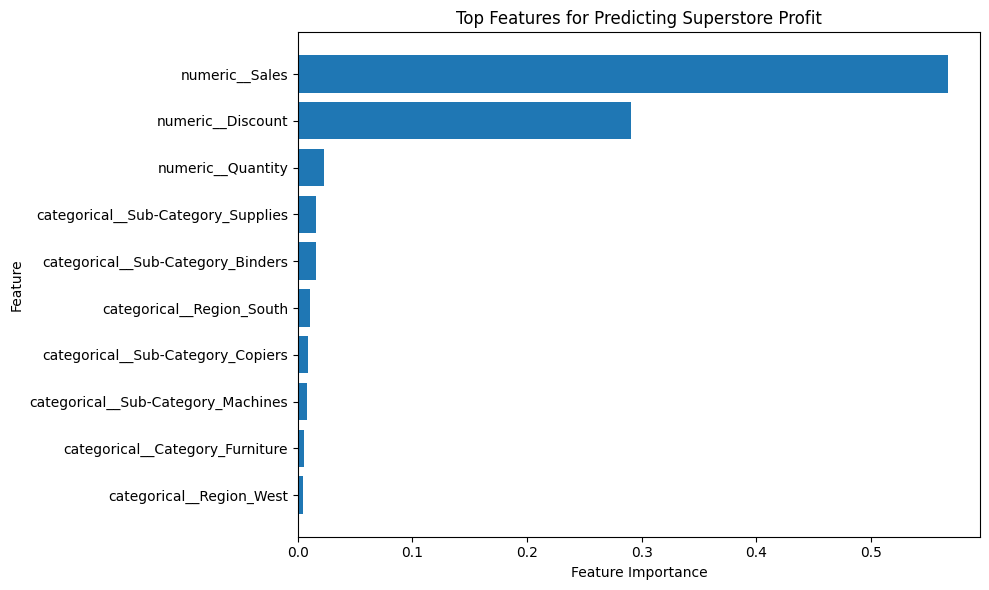

In [9]:
top_superstore = superstore_feature_importance.head(10).sort_values("Importance")

plt.figure(figsize=(10, 6))
plt.barh(top_superstore["Feature"], top_superstore["Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top Features for Predicting Superstore Profit")
plt.tight_layout()
plt.show()

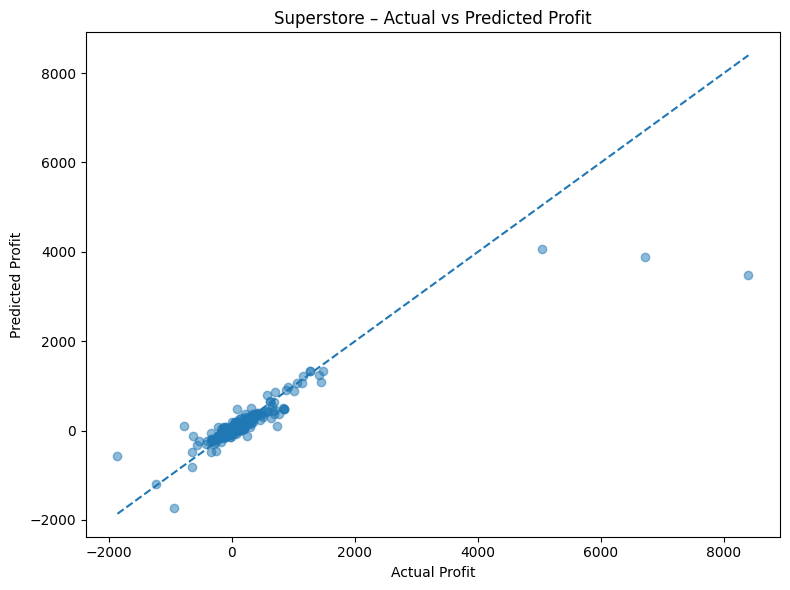

In [10]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_s, gb_predictions_s, alpha=0.5)

minimum_s = min(y_test_s.min(), gb_predictions_s.min())
maximum_s = max(y_test_s.max(), gb_predictions_s.max())

plt.plot([minimum_s, maximum_s], [minimum_s, maximum_s], linestyle="--")
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.title("Superstore – Actual vs Predicted Profit")
plt.tight_layout()
plt.show()

## Dataset 2 – Retail Store Inventory

In [11]:
inventory = pd.read_csv("retail_store_inventory.csv")

print("Retail Inventory dataset shape:", inventory.shape)
print("\nColumns:")
print(inventory.columns.tolist())

print("\nFirst five rows:")
display(inventory.head())

Retail Inventory dataset shape: (73100, 15)

Columns:
['Date', 'Store ID', 'Product ID', 'Category', 'Region', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast', 'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion', 'Competitor Pricing', 'Seasonality']

First five rows:


,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [12]:
print("Missing values:")
print(inventory.isnull().sum())

print("\nSummary statistics:")
display(
    inventory[
        [
            "Inventory Level",
            "Units Sold",
            "Units Ordered",
            "Price",
            "Discount",
            "Competitor Pricing"
        ]
    ].describe()
)

Missing values:
Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
dtype: int64

Summary statistics:


,Inventory Level,Units Sold,Units Ordered,Price,Discount,Competitor Pricing
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,55.135108,10.009508,55.146077
std,129.949514,108.919406,52.277448,26.021945,7.083746,26.191408
min,50.000000,0.000000,20.000000,10.000000,0.000000,5.030000
25%,162.000000,49.000000,65.000000,32.650000,5.000000,32.680000
50%,273.000000,107.000000,110.000000,55.050000,10.000000,55.010000
75%,387.000000,203.000000,155.000000,77.860000,15.000000,77.820000
max,500.000000,499.000000,200.000000,100.000000,20.000000,104.940000


### Retail Inventory modelling setup

The target variable is **Units Sold**. `Demand Forecast` is deliberately excluded from the predictor variables because it is already a forecast-related variable and could lead to an unrealistically easy prediction task.

In [13]:
inventory_features = [
    "Inventory Level",
    "Units Ordered",
    "Price",
    "Discount",
    "Category",
    "Region",
    "Weather Condition",
    "Holiday/Promotion",
    "Competitor Pricing",
    "Seasonality"
]

X_inventory = inventory[inventory_features]
y_inventory = inventory["Units Sold"]

numeric_inventory = [
    "Inventory Level",
    "Units Ordered",
    "Price",
    "Discount",
    "Holiday/Promotion",
    "Competitor Pricing"
]

categorical_inventory = [
    "Category",
    "Region",
    "Weather Condition",
    "Seasonality"
]

inventory_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", "passthrough", numeric_inventory),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_inventory)
    ]
)

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_inventory,
    y_inventory,
    test_size=0.20,
    random_state=42
)

print("Features used:", inventory_features)
print("Target variable: Units Sold")
print("Training records:", X_train_i.shape[0])
print("Testing records:", X_test_i.shape[0])

Features used: ['Inventory Level', 'Units Ordered', 'Price', 'Discount', 'Category', 'Region', 'Weather Condition', 'Holiday/Promotion', 'Competitor Pricing', 'Seasonality']
Target variable: Units Sold
Training records: 58480
Testing records: 14620


### Random Forest – Retail Inventory

In [14]:
rf_inventory = Pipeline(
    steps=[
        ("preprocessor", inventory_preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

rf_inventory.fit(X_train_i, y_train_i)
rf_predictions_i = rf_inventory.predict(X_test_i)

rf_mae_i = mean_absolute_error(y_test_i, rf_predictions_i)
rf_rmse_i = np.sqrt(mean_squared_error(y_test_i, rf_predictions_i))
rf_r2_i = r2_score(y_test_i, rf_predictions_i)

print("RETAIL INVENTORY - RANDOM FOREST")
print("MAE :", round(rf_mae_i, 2))
print("RMSE:", round(rf_rmse_i, 2))
print("R²  :", round(rf_r2_i, 3))

RETAIL INVENTORY - RANDOM FOREST
MAE : 69.85
RMSE: 89.93
R²  : 0.317


### Gradient Boosting – Retail Inventory

In [15]:
gb_inventory = Pipeline(
    steps=[
        ("preprocessor", inventory_preprocessor),
        ("model", GradientBoostingRegressor(
            n_estimators=100,
            random_state=42
        ))
    ]
)

gb_inventory.fit(X_train_i, y_train_i)
gb_predictions_i = gb_inventory.predict(X_test_i)

gb_mae_i = mean_absolute_error(y_test_i, gb_predictions_i)
gb_rmse_i = np.sqrt(mean_squared_error(y_test_i, gb_predictions_i))
gb_r2_i = r2_score(y_test_i, gb_predictions_i)

print("RETAIL INVENTORY - GRADIENT BOOSTING")
print("MAE :", round(gb_mae_i, 2))
print("RMSE:", round(gb_rmse_i, 2))
print("R²  :", round(gb_r2_i, 3))

RETAIL INVENTORY - GRADIENT BOOSTING
MAE : 69.02
RMSE: 88.2
R²  : 0.343


In [16]:
inventory_results = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting"],
    "MAE": [rf_mae_i, gb_mae_i],
    "RMSE": [rf_rmse_i, gb_rmse_i],
    "R2": [rf_r2_i, gb_r2_i]
})

print("Retail Inventory Model Comparison")
display(inventory_results.round(3))

Retail Inventory Model Comparison


,Model,MAE,RMSE,R2
0,Random Forest,69.847,89.933,0.317
1,Gradient Boosting,69.025,88.196,0.343


### Retail Inventory feature importance

In [17]:
feature_names_i = (
    rf_inventory
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importance_i = rf_inventory.named_steps["model"].feature_importances_

inventory_feature_importance = pd.DataFrame({
    "Feature": feature_names_i,
    "Importance": importance_i
}).sort_values("Importance", ascending=False)

print("Top 10 features for predicting Units Sold:")
display(inventory_feature_importance.head(10))

Top 10 features for predicting Units Sold:


,Feature,Importance
0,numeric__Inventory Level,0.437708
1,numeric__Units Ordered,0.113975
5,numeric__Competitor Pricing,0.111778
2,numeric__Price,0.110920
3,numeric__Discount,0.037414
4,numeric__Holiday/Promotion,0.013842
19,categorical__Seasonality_Autumn,0.010587
12,categorical__Region_North,0.010558
22,categorical__Seasonality_Winter,0.010517
11,categorical__Region_East,0.010492


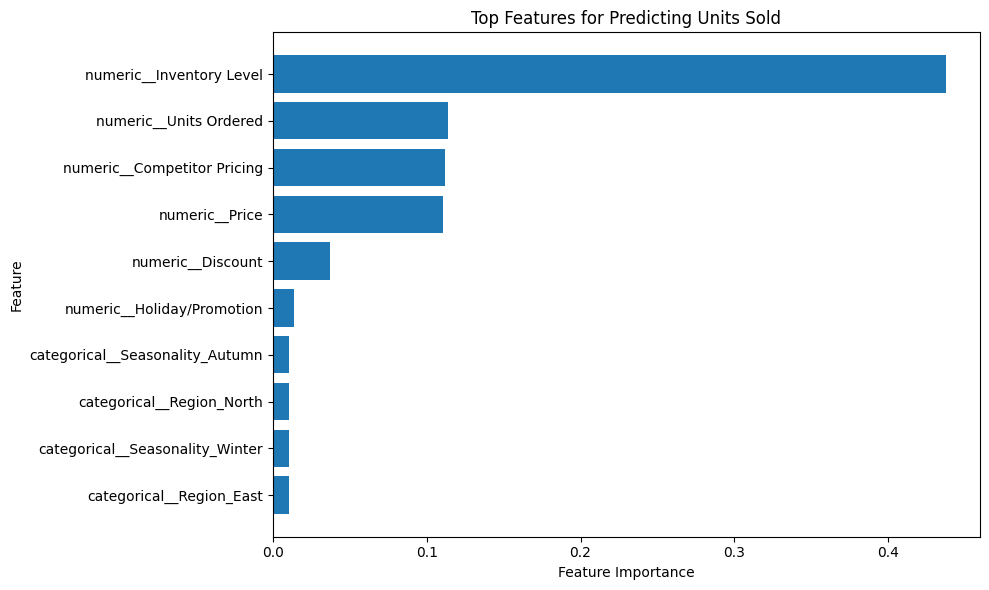

In [18]:
top_inventory = inventory_feature_importance.head(10).sort_values("Importance")

plt.figure(figsize=(10, 6))
plt.barh(top_inventory["Feature"], top_inventory["Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top Features for Predicting Units Sold")
plt.tight_layout()
plt.show()

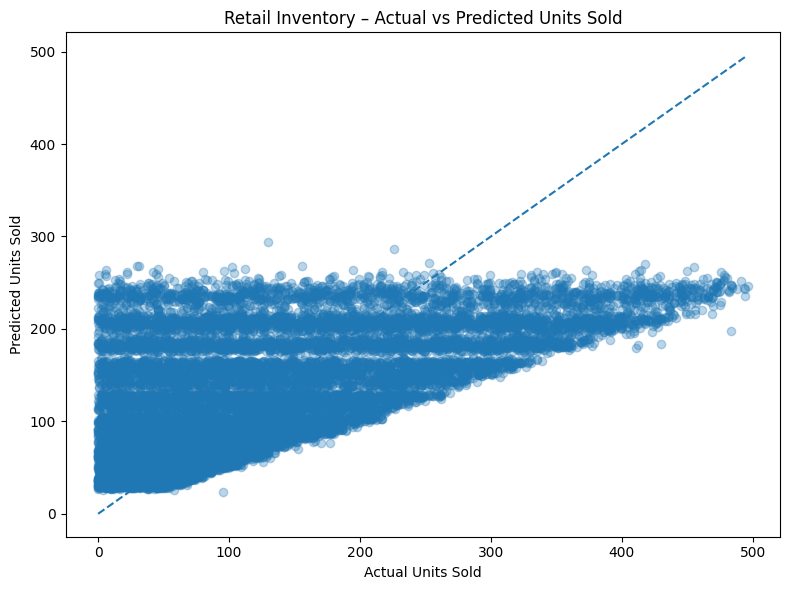

In [19]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_i, gb_predictions_i, alpha=0.3)

minimum_i = min(y_test_i.min(), gb_predictions_i.min())
maximum_i = max(y_test_i.max(), gb_predictions_i.max())

plt.plot([minimum_i, maximum_i], [minimum_i, maximum_i], linestyle="--")
plt.xlabel("Actual Units Sold")
plt.ylabel("Predicted Units Sold")
plt.title("Retail Inventory – Actual vs Predicted Units Sold")
plt.tight_layout()
plt.show()

## Final comparison

In [20]:
final_results = pd.DataFrame({
    "Dataset": [
        "Superstore",
        "Superstore",
        "Retail Inventory",
        "Retail Inventory"
    ],
    "Model": [
        "Random Forest",
        "Gradient Boosting",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        rf_mae_s,
        gb_mae_s,
        rf_mae_i,
        gb_mae_i
    ],
    "RMSE": [
        rf_rmse_s,
        gb_rmse_s,
        rf_rmse_i,
        gb_rmse_i
    ],
    "R2": [
        rf_r2_s,
        gb_r2_s,
        rf_r2_i,
        gb_r2_i
    ]
})

print("FINAL MODEL COMPARISON")
display(final_results.round(3))

FINAL MODEL COMPARISON


,Dataset,Model,MAE,RMSE,R2
0,Superstore,Random Forest,20.659,142.769,0.773
1,Superstore,Gradient Boosting,27.790,142.095,0.775
2,Retail Inventory,Random Forest,69.847,89.933,0.317
3,Retail Inventory,Gradient Boosting,69.025,88.196,0.343


In [21]:
print("MODEL SUMMARY")

print("\nSuperstore:")
if gb_r2_s > rf_r2_s:
    print("- Gradient Boosting has the higher R² score.")
else:
    print("- Random Forest has the higher R² score.")

if gb_rmse_s < rf_rmse_s:
    print("- Gradient Boosting has the lower RMSE.")
else:
    print("- Random Forest has the lower RMSE.")

if gb_mae_s < rf_mae_s:
    print("- Gradient Boosting has the lower MAE.")
else:
    print("- Random Forest has the lower MAE.")

print("\nRetail Inventory:")
if gb_r2_i > rf_r2_i:
    print("- Gradient Boosting has the higher R² score.")
else:
    print("- Random Forest has the higher R² score.")

if gb_rmse_i < rf_rmse_i:
    print("- Gradient Boosting has the lower RMSE.")
else:
    print("- Random Forest has the lower RMSE.")

if gb_mae_i < rf_mae_i:
    print("- Gradient Boosting has the lower MAE.")
else:
    print("- Random Forest has the lower MAE.")

print("\nAnalysis completed successfully.")

MODEL SUMMARY

Superstore:
- Gradient Boosting has the higher R² score.
- Gradient Boosting has the lower RMSE.
- Random Forest has the lower MAE.

Retail Inventory:
- Gradient Boosting has the higher R² score.
- Gradient Boosting has the lower RMSE.
- Gradient Boosting has the lower MAE.

Analysis completed successfully.
